# Setup

**Imports**

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from loadmydata.load_human_locomotion import (
    load_human_locomotion_dataset,
    get_code_list,
)

**Utility functions**

In [17]:
def fig_ax(figsize=(15, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.autoscale(enable=True, axis='x', tight=True)
    return fig, ax

lambda_max (sklearn) = 0.2749739760040342


/home/iliass/.local/lib/python3.11/site-packages/sklearn/base.py:1474: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/iliass/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/iliass/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+01, tolerance: 4.161e-03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_f

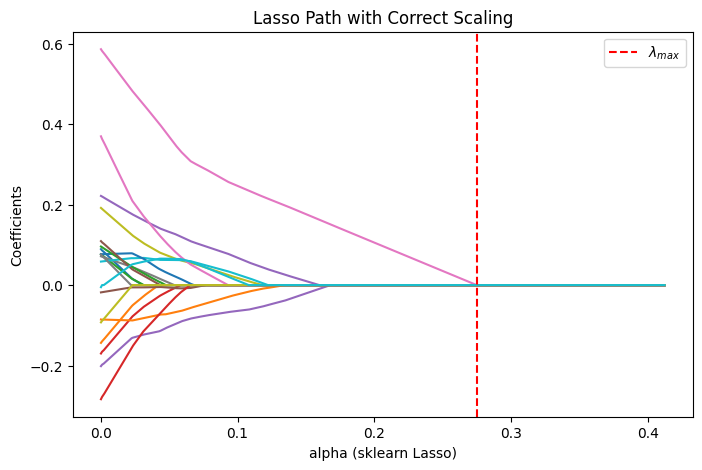

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

np.random.seed(0)
n, p = 50, 20
X = np.random.randn(n, p)
y = np.random.randn(n)

# Compute lambda_max for sklearn's scaling
lambda_max = np.max(np.abs(X.T @ y)) / n
print("lambda_max (sklearn) =", lambda_max)

# Range of alphas
alphas = np.linspace(0, 1.5 * lambda_max, 1000)
coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
    lasso.fit(X, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(8,5))
for j in range(p):
    plt.plot(alphas, coefs[:, j]) #, label=f'Beta {j}'
plt.axvline(lambda_max, color='r', linestyle='--', label=r'$\lambda_{max}$')
plt.xlabel('alpha (sklearn Lasso)')
plt.ylabel('Coefficients')
plt.title('Lasso Path with Correct Scaling')
plt.legend()
plt.savefig("lasso_path.png", dpi=300)

plt.show()


# Spectral feature

## Question 6

In [20]:
def autocovariance(x, tau, N):
    """
    Compute variance 
    
    gamma: function returning gamma(n)
    tau: lag
    N: number of samples
    """
    var = 0
    for n in range(0, N-tau):
        var += x[n]*x[n+tau]
    return var / N

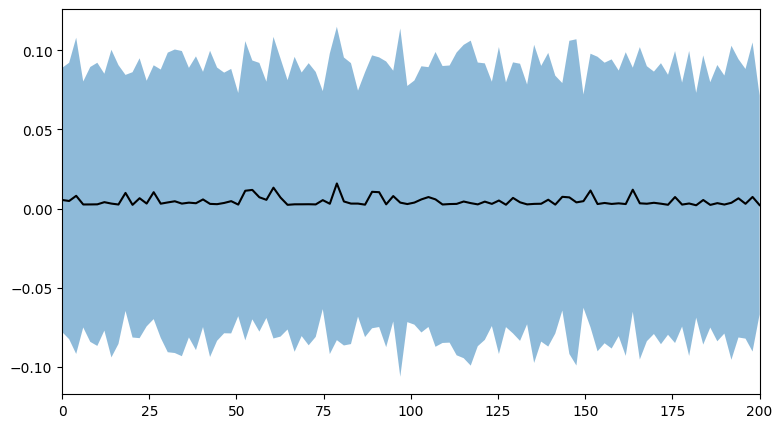

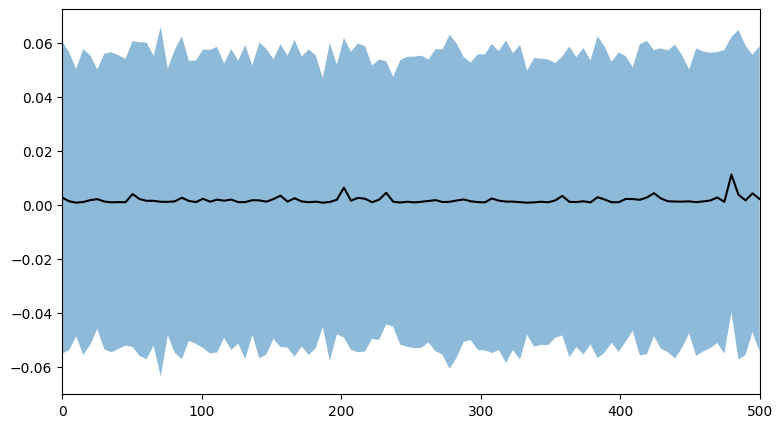

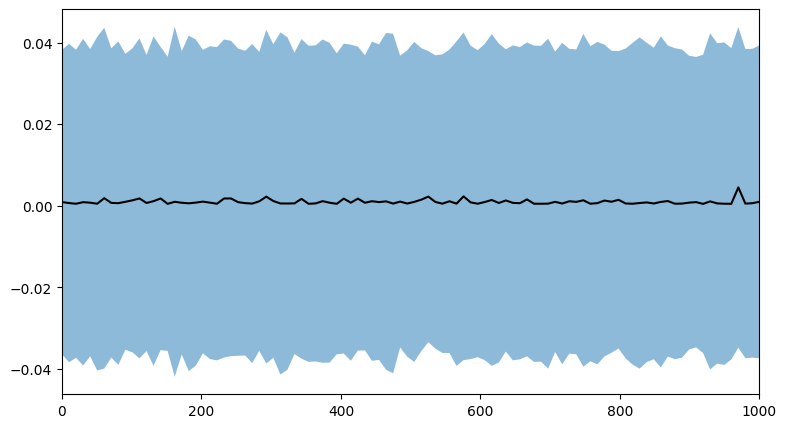

In [21]:
n_trials = 100
n_samples = [200, 500, 1000]
for N in n_samples:
    avgs = []
    stds = []
    for _ in range(100):
        X = np.random.normal(0, 1, size=N)
        autocovariances = []
        for tau in range(N):
            autocovariances.append(autocovariance(X, tau, N))
        autocovariances = np.array(autocovariances)
        avg = autocovariances.mean(axis=0)
        std = autocovariances.std(axis=0)
        avgs.append(avg)
        stds.append(std)
    avgs, stds = np.array(avgs), np.array(stds) 
    sim_n = np.linspace(0, N, 100)


    fig, ax = fig_ax(figsize=(9, 5))

    ax.plot(sim_n, avgs, 'k-')
    ax.fill_between(sim_n, avgs-stds, avgs+stds, alpha=0.5)


The next function was developped in previous course practical work (TSIA202B (Non-parametric (Spectral) Estimation) at Telecom Paris).

In [22]:
def get_periodogram(X,Bartlett= False ,Welch = False, plot = False):
    N = len(X)
    if(Bartlett):
        # Bartlett method
        freq = np.fft.fftfreq(N)
        periodogram_values = []
        
        M = int(np.sqrt(N))
        L = int(N/M)
        
        for mu in range(N):
            periodogram_r = 0
            for l in range(L):
                periodogram_ = np.fft.fft(X[l*M : l*M + M], n = N)
                periodogram_r += np.abs(periodogram_[mu]) ** 2
            periodogram_values += [periodogram_r / (L*M)]
        
        # remove negative frequencies
        periodogram_values = np.array(periodogram_values)[freq >= 0]
        freq = np.array(freq)[freq >= 0]
    elif(Welch):
        # Welch method
        freq = np.fft.fftfreq(N)
        periodogram_values = []

        # Parameters
        M = int(np.sqrt(N))
        K = int(M /2)
        S = int( 2 * N / M)

        # Window
        window = np.bartlett(M)
        P = np.sum(window**2) / M   #Power of the window
        for mu in range(N):
            periodogram_r = 0
            for i in range(S):
                if(len(X[i*K : i*K + M]) != M):
                    break
                periodogram_ = np.fft.fft(X[i*K : i*K + M]*window, n = N)
                periodogram_r += np.abs(periodogram_[mu]) ** 2
            periodogram_values += [periodogram_r]
            
        periodogram_values = periodogram_values / (S*M*P)

        # remove negative frequencies
        periodogram_values = periodogram_values[freq >= 0]
        freq = freq[freq >= 0]

    else:
        # periodogram 
        periodogram_values = np.abs(np.fft.fft(X))**2 / N
        freq = np.fft.fftfreq(N)
        # remove negative frequencies
        periodogram_values = periodogram_values[freq >= 0]
        freq = freq[freq >= 0]
    

    if(plot):
        plt.plot(freq, 10*np.log10(periodogram_values))
        plt.xlabel('Frequency')
        plt.ylabel('Periodogram')
        if (Bartlett):
            plt.title('Periodogram with Bartlett method')
        else:
            plt.title('Periodogram')
        plt.show()

    
    return freq, periodogram_values

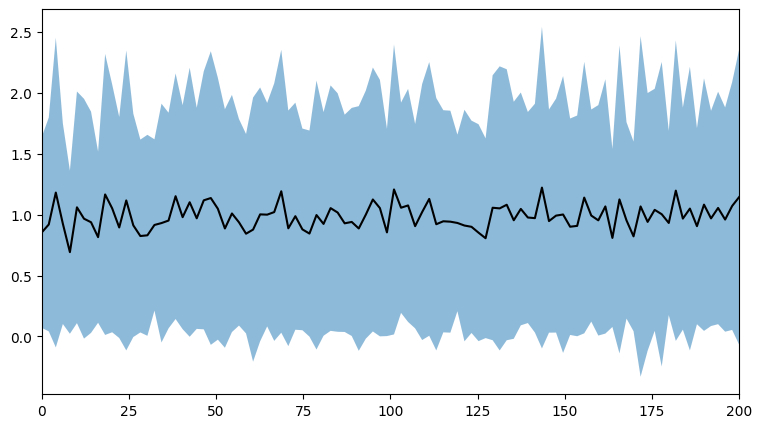

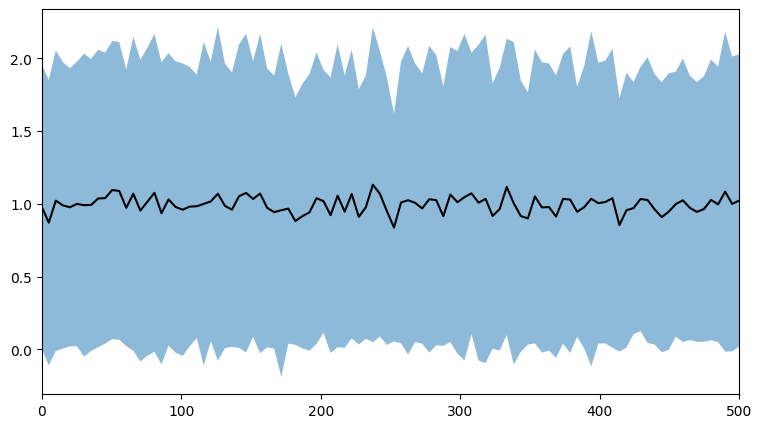

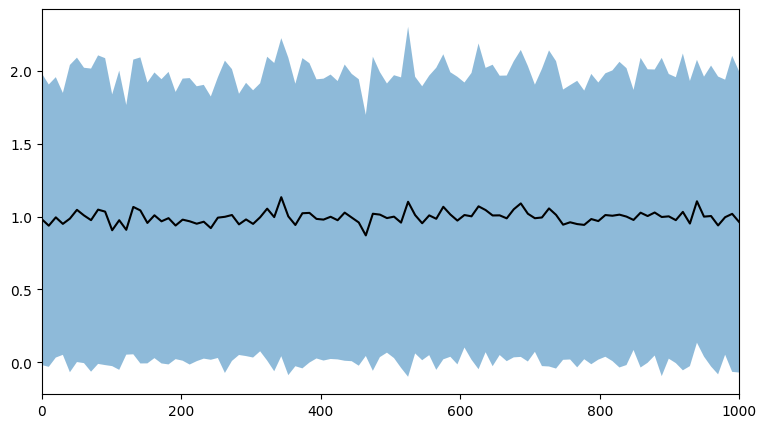

In [25]:
n_trials = 100
n_samples = [200, 500, 1000]
for N in n_samples:
    avgs = []
    stds = []
    for _ in range(100):
        X = np.random.normal(0, 1, size=N)
        freqs, periodogram = get_periodogram(X)
        avg = periodogram.mean(axis=0)
        std = periodogram.std(axis=0)
        avgs.append(avg)
        stds.append(std)
    avgs, stds = np.array(avgs), np.array(stds) 
    sim_n = np.linspace(0, N, 100)


    fig, ax = fig_ax(figsize=(9, 5))

    ax.plot(sim_n, avgs, 'k-')
    ax.fill_between(sim_n, avgs-stds, avgs+stds, alpha=0.5)


## Question 9

In [ ]:
n_trials = 100
n_samples = [200, 500, 1000]
for N in n_samples:
    avgs = []
    stds = []
    for _ in range(100):
        X = np.random.normal(0, 1, size=N)
        freqs, periodogram = get_periodogram(X, Bartlett=True)
        avg = periodogram.mean(axis=0)
        std = periodogram.std(axis=0)
        avgs.append(avg)
        stds.append(std)
    avgs, stds = np.array(avgs), np.array(stds) 
    sim_n = np.linspace(0, N, 100)


    fig, ax = fig_ax(figsize=(9, 5))

    ax.plot(sim_n, avgs, 'k-')
    ax.fill_between(sim_n, avgs-stds, avgs+stds, alpha=0.5)


# Dynamic time warping (DTW)

## Data

This data set consists of signals collected with inertial measurement units (accelerometer+gyroscope), from 230 subjects undergoing a fixed protocol:
- standing still,
- walking 10 m,
- turning around,
- walking back,
- stopping.

In this assignment, we only consider the vertical acceleration of the left foot and all signals are truncated to 20 seconds (as a result, they all have same length). Signals are sampled at 100 Hz.

The measured population is composed of healthy subjects as well as patients with neurological or orthopedic disorders.

The start and end time stamps of thousands of footsteps are available.

The data are part of a larger data set described in [1].

[1] Truong, C., Barrois-Müller, R., Moreau, T., Provost, C., Vienne-Jumeau, A., Moreau, A., Vidal, P.-P., Vayatis, N., Buffat, S., Yelnik, A., Ricard, D., & Oudre, L. (2019). A data set for the study of human locomotion with inertial measurements units. Image Processing On Line (IPOL), 9.

**The task** is to classify footsteps in healthy/non-healthy.

The following cell defines the training set `(X_train, y_train)` and testing set `(X_test, y_test)`.

In [ ]:
subset_indexes_train = [95, 619, 441, 149, 951, 803, 214, 34, 37, 630]
subset_indexes_test = [683, 259, 59, 387, 634]

code_list = get_code_list()

X_train = list()  # list of footstep signals
y_train = list()  # list of pathologies (the "labels")

for code in np.take(code_list, subset_indexes_train):
    single_trial = load_human_locomotion_dataset(code)
    signal = single_trial.signal.LAZ.to_numpy()  # keeping only one dimension (from the left sensor)
    steps = single_trial.left_steps
    pathology = single_trial.metadata["PathologyGroup"]
    label = 0 if pathology=="Healthy" else 1  # 0: healthy, 1: non-healthy
    for (start, end) in steps:
        X_train.append(signal[start:end])
        y_train.append(label)

        
X_test = list()  # list of footstep signals
y_test = list()  # list of pathologies (the "labels")

for code in np.take(code_list, subset_indexes_test):
    single_trial = load_human_locomotion_dataset(code)
    signal = single_trial.signal.LAZ.to_numpy()  # keeping only one dimension (from the left sensor)
    steps = single_trial.left_steps
    pathology = single_trial.metadata["PathologyGroup"]
    label = 0 if pathology=="Healthy" else 1  # 0: healthy, 1: non-healthy
    for (start, end) in steps:
        X_test.append(signal[start:end])
        y_test.append(label)

AssertionError: The code 17-1 cannot be found in the data set.

## Question 10

## Question 11